In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind, t, sem

def plot_gene_expression_summary(adata, top_genes, category, title=None, ax=None):
    # Préparation des données fondues
    melted = (
        adata[:, top_genes].to_df()
        .assign(**{category: adata.obs[category].values})
        .melt(id_vars=category, var_name="gene", value_name="expression")
    )

    # Détection des niveaux de groupe
    group_levels = (
        list(adata.obs[category].cat.categories)
        if hasattr(adata.obs[category], "cat")
        else sorted(adata.obs[category].unique())
    )

    # Calcul des statistiques
    summary_stats = (
        melted.groupby(["gene", category], observed=False)
        .agg(mean_expression=("expression", "mean"),
             count=("expression", "count"),
             std=("expression", "std"))
        .reset_index()
    )

    summary_stats["std"] = summary_stats["std"].fillna(0.0)
    summary_stats["sem"] = summary_stats["std"] / np.sqrt(summary_stats["count"].clip(lower=1))
    df_dof = (summary_stats["count"] - 1).clip(lower=1)
    summary_stats["ci95"] = t.ppf(0.975, df_dof) * summary_stats["sem"]
    summary_stats.loc[summary_stats["count"] <= 1, "ci95"] = 0.0

    # Pivots
    mean_pivot = (
        summary_stats.pivot(index="gene", columns=category, values="mean_expression")
        .reindex(top_genes)
        .reindex(columns=group_levels)
        .fillna(0.0)
    )
    ci_pivot = (
        summary_stats.pivot(index="gene", columns=category, values="ci95")
        .reindex(top_genes)
        .reindex(columns=group_levels)
        .fillna(0.0)
    )

    # Tests Mann-Whitney pour deux groupes
    pvalues = {}
    if len(group_levels) == 2:
        for gene in top_genes:
            gene_vals = melted[melted["gene"] == gene]
            grp1 = gene_vals[gene_vals[category] == group_levels[0]]["expression"]
            grp2 = gene_vals[gene_vals[category] == group_levels[1]]["expression"]
            _, pval = mannwhitneyu(grp1, grp2, alternative='two-sided')
            pvalues[gene] = pval

    def star_from_pvalue(p):
        if p < 1e-4:
            return "****"
        if p < 1e-3:
            return "***"
        if p < 1e-2:
            return "**"
        if p < 5e-2:
            return "*"
        return ""

    # Graphique
    x = np.arange(len(top_genes))
    bar_width = 0.35

    if ax is None:
        fig_bar, ax_bar = plt.subplots(figsize=(14, 6))
    else:
        ax_bar = ax
    
    # Définir les couleurs pour True (vert) et False (rouge)
    color_map = {"True": 'green', "False": 'red'}
        
    for idx, level in enumerate(group_levels):
        offsets = (idx - (len(group_levels) - 1) / 2) * bar_width
        means = mean_pivot[level].to_numpy()
        cis = ci_pivot[level].to_numpy()
        color = color_map.get(level, 'gray')
        ax_bar.bar(
            x + offsets,
            means,
            width=bar_width,
            yerr=cis,
            capsize=5,
            label=level,
            alpha=0.8,
            color=color
        )

    if len(group_levels) == 2:
        max_height = (mean_pivot + ci_pivot).values.max()
        for gene_idx, gene in enumerate(top_genes):
            pval = pvalues.get(gene)
            stars = star_from_pvalue(pval) if pval is not None else ""
            if stars:
                positions = x[gene_idx] + np.array(
                    [(i - (len(group_levels) - 1) / 2) * bar_width for i in range(len(group_levels))]
                )
                top_vals = mean_pivot.loc[gene, group_levels].to_numpy() + ci_pivot.loc[gene, group_levels].to_numpy()
                y = top_vals.max() + 0.15 * max_height / 6
                h = 0.05 * max_height
                ax_bar.plot([positions[0], positions[0], positions[1], positions[1]],
                            [y, y + h, y + h, y], color="black", linewidth=1)
                ax_bar.text(positions.mean(), y + h + 0.02 * max_height, stars,
                            ha="center", va="bottom", fontsize=12)
                

    ax_bar.set_ylabel("Expression")
    if title:
        ax_bar.set_title(title)
    else:
        ax_bar.set_title(f"Expression of top genes by {category} (95% CI)")
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(top_genes, rotation=45, ha="right")
    ax_bar.legend(title=category)
    ax_bar.grid(axis="y", linestyle="--", alpha=0.3)
    ax_bar.set_ylim(0, (mean_pivot + ci_pivot).values.max() * 1.5)

    if ax is None:
        ax_bar.set_xlabel("Gene")
        plt.show()
    else:
        return ax_bar

In [2]:
adata_sigma = sc.read_h5ad("/mnt/scratch/guillaume/results_dominguez/merge.h5ad")
adata_author = sc.read_h5ad("/mnt/scratch/guillaume/data/tem_dominguez/Dominguez_science_science-abl5197.h5add")

adata_author.X = adata_author.layers["counts"]

adata_sigma.obs_names = [re.sub(r"-Dominguez_[A-Z]+", "", name) for name in adata_sigma.obs_names]
adata_sigma.obs_names = [re.sub(r"(JEJLP|JEJEPI|)$", "", name) for name in adata_sigma.obs_names]

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/scratch/guillaume/results_dominguez/merge.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [3]:
adata_sumry = ad.AnnData(adata_author.X)

# Add var table
adata_sumry.var_names = adata_author.var_names

# Add UMAP coordinates
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]

# Add counts table
adata_sumry.layers["raw"] = adata_author.layers["counts"]
adata_sumry.layers["log1p"] = adata_author.X

# Add obs table
adata_sumry.obs_names = adata_author.obs_names
adata_sumry.obs["donor"] = adata_author.obs["Donor"]
adata_sumry.obs["sex"] = adata_author.obs["Sex"]
adata_sumry.obs["age"] = adata_author.obs["Age_range"]
adata_sumry.obs["organ"] = adata_author.obs["Organ"]
adata_sumry.obs["assay"] = adata_author.obs["Chemistry"]
adata_sumry.obs["celltype"] = adata_author.obs["Predicted_labels_CellTypist"]

adata_sumry.obs["score"] = 0.0
adata_sumry.obs.loc[adata_sigma.obs_names, "score"] = adata_sigma.obs["score"].values

proba_cols = [col for col in adata_sigma.obs.columns if col.startswith("proba_")]
for prob in proba_cols:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)
adata_sumry

AnnData object with n_obs × n_vars = 329762 × 36601
    obs: 'donor', 'sex', 'age', 'organ', 'assay', 'celltype', 'score', 'proba_target', 'proba_LowIn'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'raw', 'log1p'

# Score plot

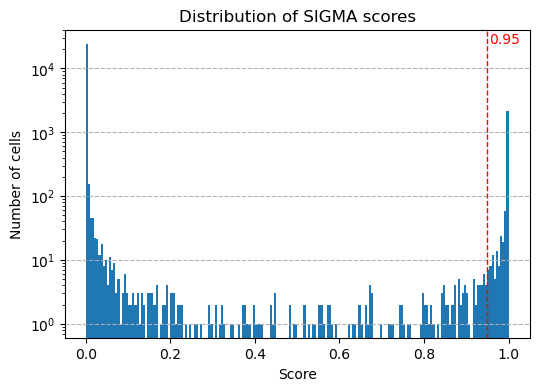

In [4]:
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(adata_sigma.obs["score"], bins=200)
ax.set_xlabel("Score")
ax.set_ylabel("Number of cells")
ax.set_yscale("log")
ax.set_title("Distribution of SIGMA scores")
ax.grid(axis='y', linestyle='--')
ax.axvline(0.95, color='red', linestyle='--', linewidth=1)
ax.text(0.955, ax.get_ylim()[1]*0.9, "0.95", color='red', ha='left', va='top')

fig.savefig("figures/dominguez_Score.svg", bbox_inches="tight", dpi=300)
plt.show()

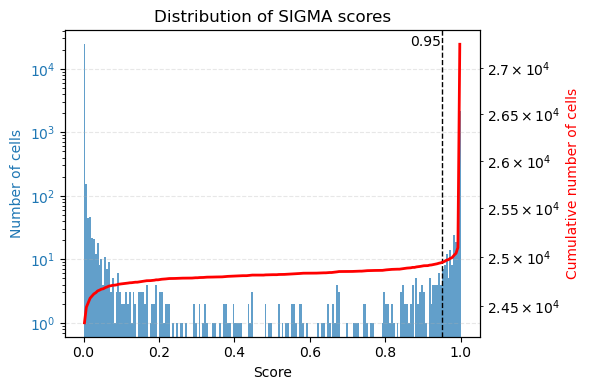

In [11]:
fig, ax1 = plt.subplots(figsize=(6,4))

# Histogramme
n, bins, patches = ax1.hist(adata_sigma.obs["score"], bins=200, alpha=0.7, label='Count')
ax1.set_xlabel("Score")
ax1.set_ylabel("Number of cells", color='C0')
ax1.set_yscale("log")
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Somme cumulée sur un second axe
ax2 = ax1.twinx()
cumsum = np.cumsum(n)
bin_centers = (bins[:-1] + bins[1:]) / 2
ax2.plot(bin_centers, cumsum, color='red', linewidth=2, label='Cumulative sum')
ax2.set_ylabel("Cumulative number of cells", color='red')
ax2.set_yscale("log")
ax2.tick_params(axis='y', labelcolor='red')

# Ligne verticale à 0.95
ax1.axvline(0.95, color='black', linestyle='--', linewidth=1)
ax1.text(0.865, ax1.get_ylim()[1]*0.85, "0.95", color='black', ha='left', va='top')

ax1.set_title("Distribution of SIGMA scores")
fig.tight_layout()
fig.savefig("figures/dominguez_Score_cumulative.svg", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
is_tem_sigma = adata_sumry.obs["score"] >= 0.95
adata_sumry.obs["Identified by SIGMA"] = is_tem_sigma.astype(str)

adata_sumry.obs["Identified by SIGMA"] = pd.Categorical(
    adata_sumry.obs["Identified by SIGMA"],
    categories=["True", "False"],
    ordered=True
)

sub_adata_sumry = adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "True"]

In [118]:
sub_adata_sumry

View of AnnData object with n_obs × n_vars = 2329 × 36601
    obs: 'donor', 'sex', 'age', 'organ', 'assay', 'celltype', 'score', 'proba_target', 'proba_LowIn', 'is_tem_sigma', 'Identified by SIGMA'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'raw', 'log1p'

/tmp/ipykernel_61054/285311406.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


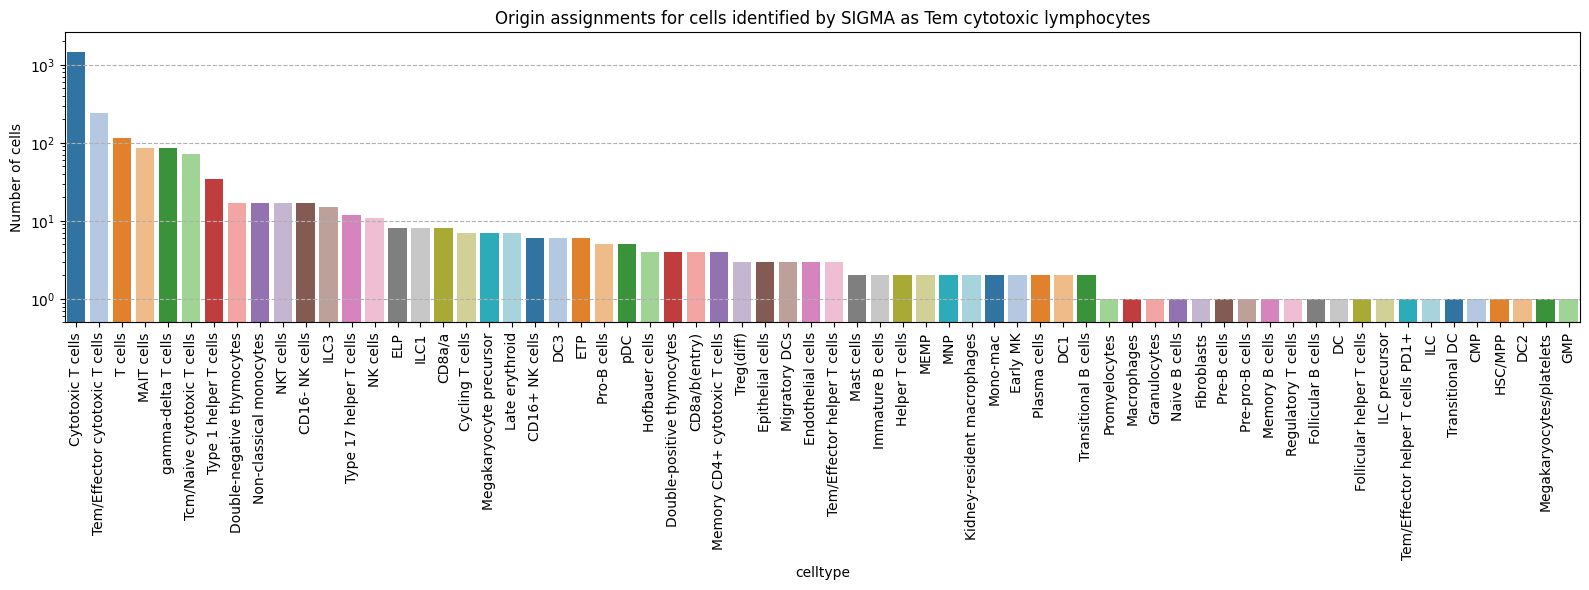

In [117]:
import seaborn as sns

celltype_counts = (
    sub_adata_sumry.obs['celltype']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'celltype'})
    .sort_values('count', ascending=False)
)

celltype_counts['celltype'] = celltype_counts['celltype'].astype(str)

plt.figure(figsize=(16, 6))
ax = sns.barplot(
    data=celltype_counts,
    x='celltype',
    y='count',
    hue='celltype',
    palette='tab20',
    dodge=False,
    order=celltype_counts['celltype']
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.ylabel('Number of cells')
plt.grid(axis='y', linestyle='--')
plt.yscale('log')
plt.ylim(0.5, celltype_counts['count'].max()*1.8)
plt.title("Origin assignments for cells identified by SIGMA as Tem cytotoxic lymphocytes")

# # Ajouter les chiffres au-dessus des barres
# for p in ax.patches:
#     height = p.get_height()
#     if np.isfinite(height):
#         label = f'{int(height):,}'.replace(',', ' ')
#         ax.text(
#             p.get_x() + p.get_width() / 2.,
#             height * 1.05 if height > 0 else 0.5,
#             label,
#             ha='center',
#             va='bottom',
#             fontsize=9
#         )

# Extract colors from the current plot and store in color_mapping
color_mapping = {}
for patch, celltype in zip(ax.patches, celltype_counts['celltype']):
    color_mapping[celltype] = patch.get_facecolor()

plt.tight_layout()
plt.savefig("figures/dominguez_CelltypeDistribution.svg", dpi=300)
plt.show()

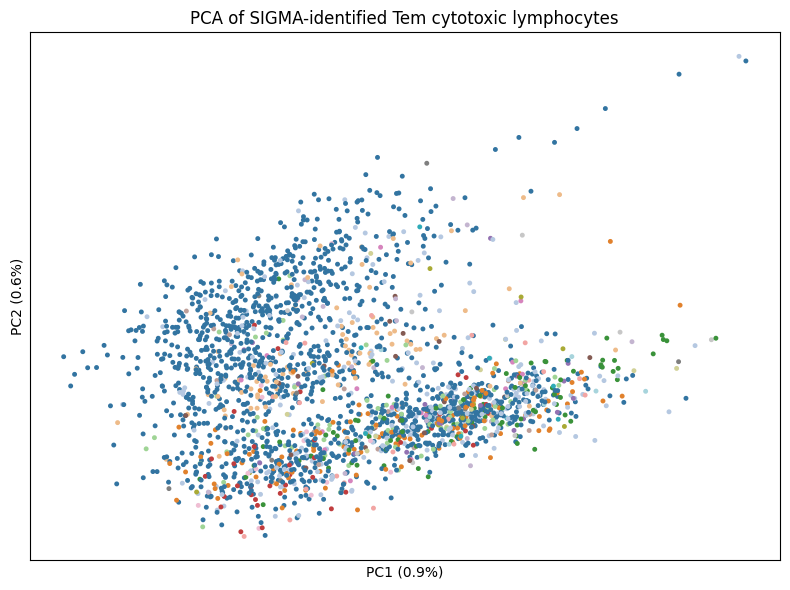

In [98]:
# PCA plot
fig2, ax2 = plt.subplots(figsize=(8, 6))

pc_var = sub_adata_sumry.uns['pca']['variance_ratio']
sc.pl.pca(
    sub_adata_sumry,
    s=50,
    color='celltype',
    palette=color_mapping,
    legend_loc='none',
    show=False,
    ax=ax2
)

ax2.set_xlabel(f'PC1 ({pc_var[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pc_var[1]*100:.1f}%)')
ax2.set_title('PCA of SIGMA-identified Tem cytotoxic lymphocytes')

plt.tight_layout()
plt.savefig("figures/dominguez_PCA.svg", dpi=300, bbox_inches="tight")
plt.show()


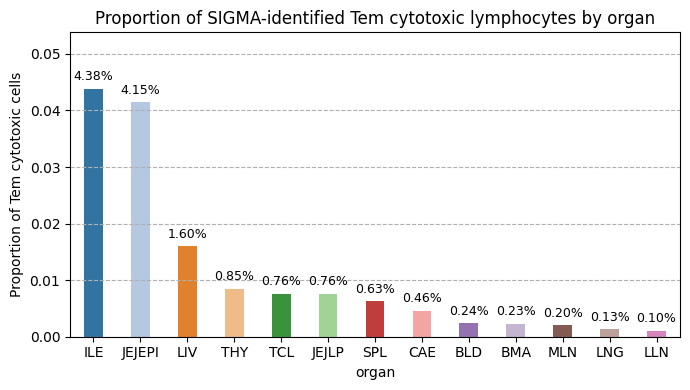

In [108]:
# Plot proportion of Tem cells per organ
organ_counts = (
    sub_adata_sumry.obs['organ']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'organ'})
    .sort_values('count', ascending=False)
)

for org in organ_counts['organ']:
    ncells_in_org = adata_sumry.obs['organ'].value_counts().get(org, 0)
    organ_counts.loc[organ_counts['organ'] == org, 'proportion'] = (
        organ_counts.loc[organ_counts['organ'] == org, 'count'].values[0] / ncells_in_org
        if ncells_in_org > 0 else 0.0
    )

# sort by proportion descending
organ_counts = organ_counts.sort_values('proportion', ascending=False).reset_index(drop=True)
organ_counts['organ'] = organ_counts['organ'].astype(str)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=organ_counts,
    x='organ',
    y='proportion',
    hue='organ',
    palette='tab20',
    dodge=False,
    width=0.4,
    order=organ_counts['organ'].tolist()
)
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.set_ylabel('Proportion of Tem cytotoxic cells')
ax.set_ylim(0, organ_counts['proportion'].max()+0.01 if organ_counts['proportion'].max() > 0 else 1)
plt.grid(axis='y', linestyle='--')
plt.title("Proportion of SIGMA-identified Tem cytotoxic lymphocytes by organ")

# Add percentage labels above bars
for p in ax.patches:
    height = p.get_height()
    if np.isfinite(height):
        label = f'{height:.2%}'
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.001 if height > 0 else 0.01,
            label,
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.savefig("figures/dominguez_OrganDistribution.svg", dpi=300, bbox_inches="tight")
plt.show()

# Pourquoi tous les TEM cyto n'ont pas été trouvé ?

In [109]:
tem_author = adata_sumry[adata_sumry.obs["celltype"] == "Tem/Effector cytotoxic T cells"]
tem_author

View of AnnData object with n_obs × n_vars = 9749 × 36601
    obs: 'donor', 'sex', 'age', 'organ', 'assay', 'celltype', 'score', 'proba_target', 'proba_LowIn', 'is_tem_sigma', 'Identified by SIGMA'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'raw', 'log1p'

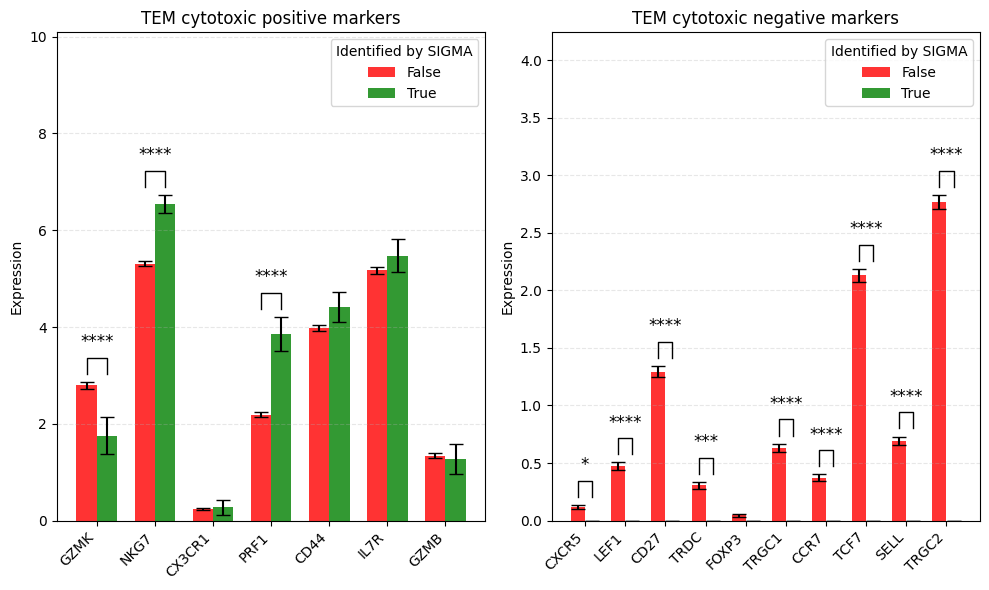

In [116]:
positive_mark = ['GZMK', 'NKG7', 'CX3CR1', 'PRF1', 'CD44', 'IL7R', 'GZMB']
negative_mark = ['CXCR5', 'LEF1', 'CD27', 'TRDC', 'FOXP3', 'TRGC1', 'CCR7', 'TCF7', 'SELL', 'TRGC2']

fig, ax = plt.subplots(1,2, figsize=(10, 6))

plot_gene_expression_summary(tem_author, positive_mark, "Identified by SIGMA", "TEM cytotoxic positive markers", ax=ax[0])
plot_gene_expression_summary(tem_author, negative_mark, "Identified by SIGMA", "TEM cytotoxic negative markers", ax=ax[1])

plt.tight_layout()
plt.savefig("figures/dominguez_TemMarkers.svg", dpi=300, bbox_inches="tight")
plt.show()